# Elife Paper 
## Figure 6L: Neural Activity


In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import json
import pickle
# import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from matplotlib.gridspec import GridSpec
from matplotlib import cm, colors
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap

Base parameters loaded from params.yaml


In [8]:
# # load parameters from json file
# params_path = "params_6.json" # yeah we are using the old one again, its good shit
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 20,
                            #    "params.RECORD_WEIGHTS": 0,
                            #    "params.BG_NOISE": 0.2,
                            #    "const.HVC_SIZE":20
                           } )
# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 40
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING)                  
print(f'Random seed is {RANDOM_SEED}')

1
Random seed is 40


In [3]:
# Config
# 1 to load model
# 1 to save model
load = 0
save = 0
model_version = "model_20"  # e.g., "model","model_1" "model20", "model_4_40", "model_syrinx_4_41"etc.

model_path = f"{model_version}.pkl"

if load:
    if os.path.exists(model_path):
        with open(model_path, 'rb') as f:
            obj = pickle.load(f)
            print(f"Model '{model_version}' loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file '{model_path}' not found.")

else:
    obj = Environment(RANDOM_SEED, parameters, NN)
    obj.run(parameters, ANNEALING)

    if save:
        if os.path.exists(model_path):
            print(f"Model file '{model_path}' already exists. Not overwriting.")
        else:
            try:
                pickle.dumps(obj)  # Test serialization
                with open(model_path, "wb") as f:
                    pickle.dump(obj, f)
                print(f"Model '{model_version}' saved successfully.")
            except pickle.PicklingError:
                print("Object cannot be pickled!")


  0%|          | 0/60 [00:00<?, ?it/s]

100%|██████████| 60/60 [03:47<00:00,  3.80s/it]


In [3]:
# # Poisson Spike Plotter
# def spike_plotter_poisson(rate_array, size_of_time_bin, scaling_factor = 1, rate_max=400, dt = 0.001, state=42):
#     time_bins, channels = rate_array.shape
#     # dt = 0.02 / time_points_per_rate  # 20ms per coarse bin, divided into fine bins
#     scaling_factor = rate_max * 0.02  # 0.02s = 20ms

#     spike_raster = np.zeros((time_bins * size_of_time_bin, channels), dtype=int)
#     np.random.seed(state)
#     for c in range(channels):
#         for t in range(time_bins):
#             start = t * size_of_time_bin
#             end = (t + 1) * size_of_time_bin
#             # Compute expected spike count (lambda) for this 20ms window
#             rate = squash(rate_array[t, c], p=20, a=0.00) * scaling_factor # rate from 0-1 to 0-8 spikes per timestep
#             # np.random.seed(state + c + 2*t + c*t) 
#             spike_count = np.random.poisson(rate* rate_max * dt) 
#             # print(spike_count, rate)

#             # Randomly assign spike_count spikes within the window
#             if spike_count > 0:
#                 spike_times = np.random.choice(size_of_time_bin, size=spike_count, replace=False)
#                 spike_raster[start + spike_times, c] = 1
#     return spike_raster


In [13]:
def poisson_eventplot_from_rates(
    rate_array,
    bin_size_ms,
    rate_max=400,
    rate_min = 0.6,
    refractory_ms=0.0,
    seed=None,
):
    if seed is not None:
        np.random.seed(seed)

    time_bins, channels = rate_array.shape
    DT = bin_size_ms / 1000.0
    tau_ref = refractory_ms / 1000.0

    spike_times_all_channels = [[] for _ in range(channels)]

    for c in range(channels):
        last_spike_time = -np.inf  # track across bins

        for t in range(time_bins):
            r = rate_array[t, c] * (rate_max - rate_min) + rate_min  # scale to [rate_min, rate_max]
            k = np.random.poisson(r * DT)

            if k > 0:
                start_time = t * DT
                spikes = start_time + np.random.uniform(0, DT, size=k)
                spikes.sort()

                for s in spikes:
                    if s - last_spike_time >= tau_ref:
                        spike_times_all_channels[c].append(s)
                        last_spike_time = s

    spike_times_all_channels = spike_times_all_channels[::-1]
    time = np.linspace(0, time_bins * DT, time_bins + 1)

    return spike_times_all_channels, time


[[0.11111111 0.22222222 0.33333333]
 [0.44444444 0.55555556 0.66666667]
 [0.77777778 0.88888889 1.        ]]


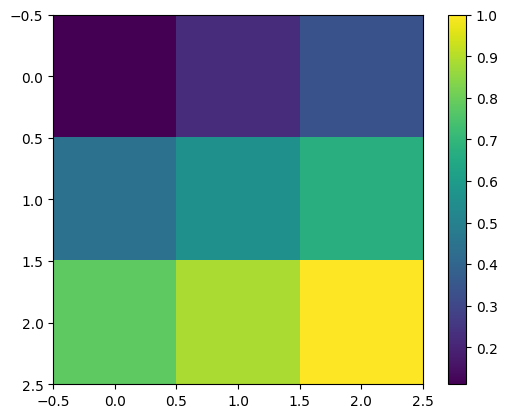

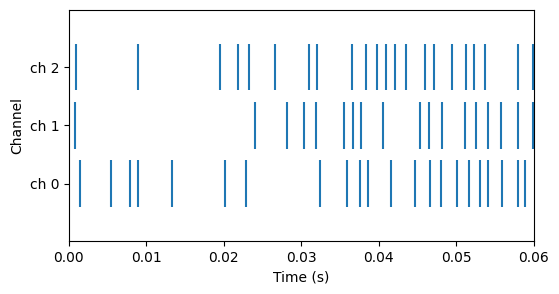

In [14]:
array = [[1,2,3],[4,5,6],[7,8,9]]
array/=np.max(array)
print(array)
plt.imshow(array, cmap='viridis')
plt.colorbar()
plt.show()

spikes, time = poisson_eventplot_from_rates(array, bin_size_ms=20, rate_max=1000, refractory_ms=1)

plt.figure(figsize=(6, 3))
plt.eventplot(
    spikes,
    orientation="horizontal",
    lineoffsets=np.arange(len(spikes)),
    linelengths=0.8,
)
plt.xlim(0, time[-1])
plt.yticks(np.arange(len(spikes)), labels=[f"ch {i}" for i in range(len(spikes))])
plt.xlabel("Time (s)")
plt.ylabel("Channel")
plt.show()

### A: HVC Neurons

HVC array shape: (60, 1000, 20, 100)


/tmp/ipykernel_35277/1023577823.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


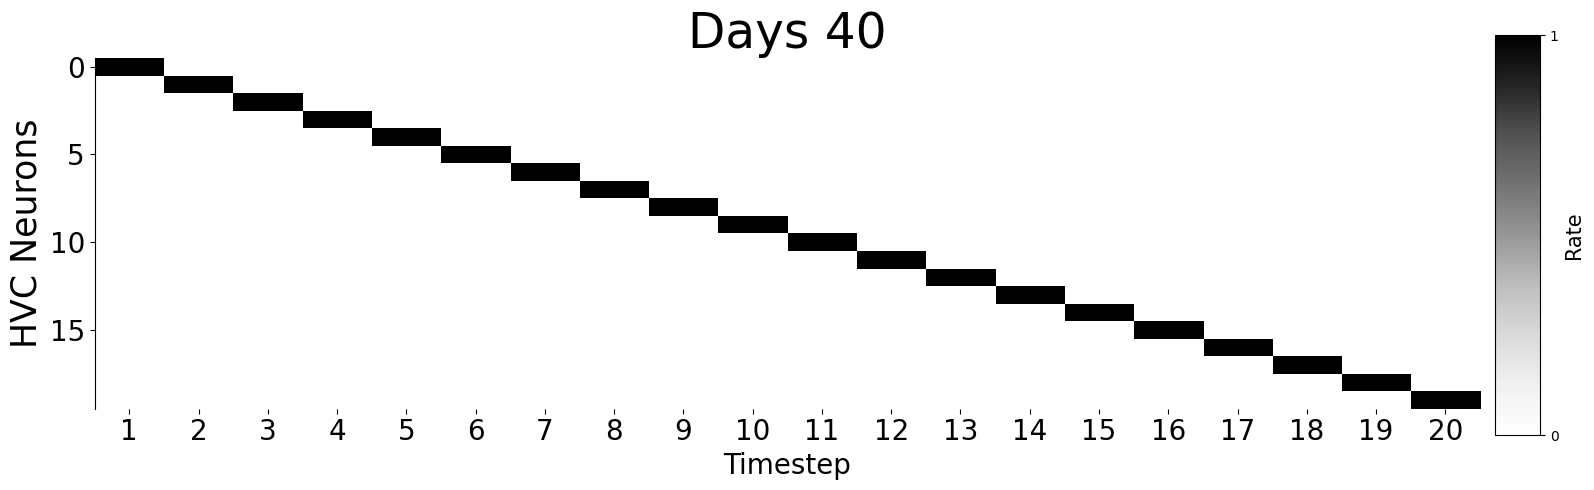

/tmp/ipykernel_35277/1023577823.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


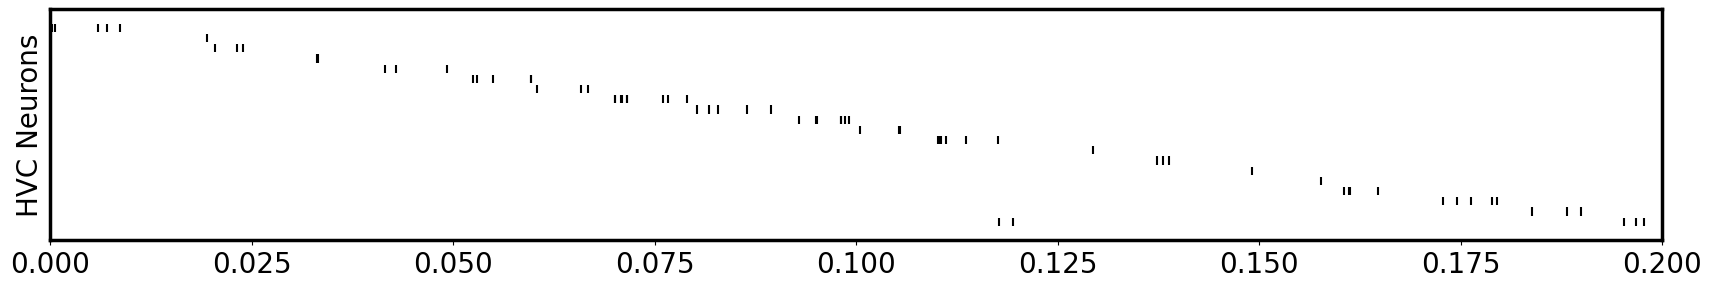

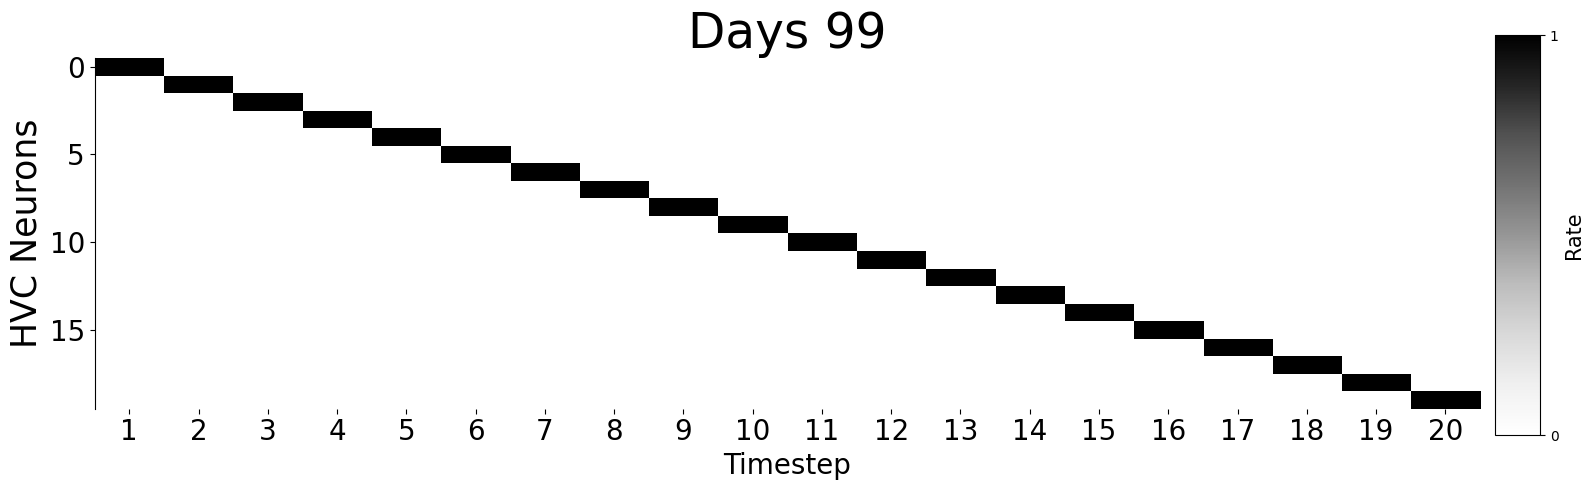

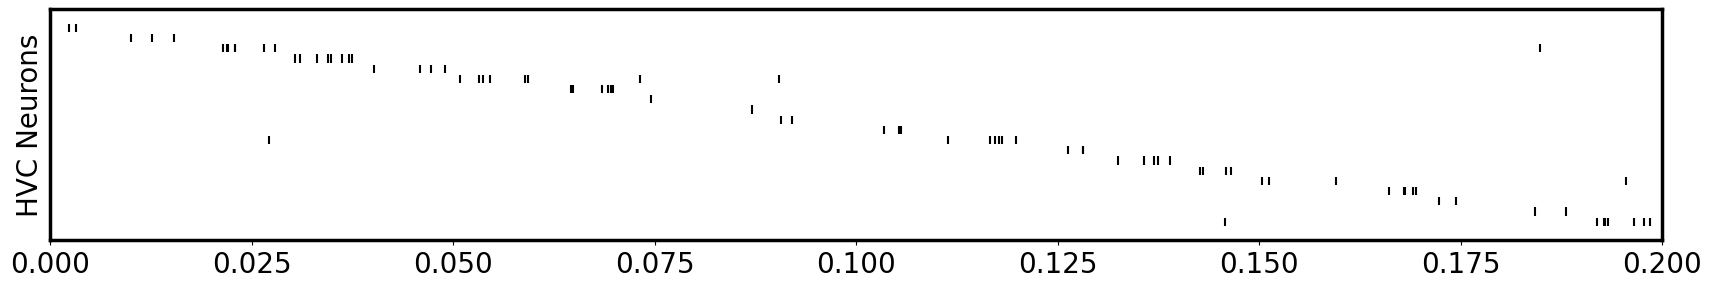

In [16]:
hvc_neurons = 100
hvc_array_all = np.zeros((DAYS, TRIALS, N_SYLL, hvc_neurons))

# Create one-hot vector for each syllable
one_hot = np.eye(hvc_neurons)[np.arange(N_SYLL)]  # shape: (N_SYLL, hvc_neurons)

# Broadcast across days and trials
hvc_array_all[:, :, :, :] = one_hot[np.newaxis, np.newaxis, :, :]

print("HVC array shape:", hvc_array_all.shape)  # Should be (DAYS, TRIALS, N_SYLL, hvc_neurons)

def plot_HVC_motifs_days_rate(day):
    """ Plots the model output over time. """
    alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']  
    figure, (ax1) = plt.subplots(1, figsize=(15,5))
    nos_trials_per_day = 1
    nos_neurons = 20
    plot_array = hvc_array_all[day, :nos_trials_per_day,:,:nos_neurons].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T
    # plt.hist(plot_array.flatten(), bins=100, color='black', alpha=0.5)
    # plt.show()
    # plot_array = sigmoid(plot_array, m=1, a=0)
    # spike_raster = bin_and_plot_spikes(sigmoid(plot_array, m=1, a=0), factor=1, bin_size= 6)
    # spike_raster = plot_array
    im1 = ax1.imshow(plot_array.T, aspect='auto', cmap='Greys', interpolation='nearest', vmin = 0, vmax = 1)   
    figure.subplots_adjust(right=1.2)
    cbar_ax = figure.add_axes([1.00, 0.12, 0.03, 0.8])
    cbar = figure.colorbar(im1, cax=cbar_ax)
    cbar.set_label('Rate', fontsize=15)
    cbar.set_ticks([0, 1])
    # ax1.vlines(x=-0.5+np.arange(0, nos_trials_per_day*N_SYLL, N_SYLL), ymin =-0.5 , ymax = 7.5,  color='yellow', lw=1, label='Trials') 
    # ax1.set_xlim(0, 10*N_SYLL)
    # ax1.set_xticks(np.arange(0, N_SYLL*nos_trials_per_day*5, N_SYLL*nos_trials_per_day), day + np.arange(0, 5,1), fontsize=15)
    # ax1.set_xlim(0, 10*N_SYLL)
    # ax1.set_xticks()
    # ax1.set_xticks(np.arange(0, N_SYLL*10, N_SYLL), np.arange(0, 10), fontsize=15)
    # ax1.hlines(y = np.arange(nos_neurons*8+1)-0.5, xmin = -0.5, xmax = N_SYLL*1-0.5, color='white', alpha = 0.1)
    # ax1.hlines(y = np.arange(0,nos_neurons*8,8)-0.5, xmin = -0.5, xmax = N_SYLL*1-0.5, color='white', lw=1)      
    # ax1.set_yticks([])  
    # ax1.set_yticks(np.arange(8*nos_neurons), np.tile(np.arange(1, 9), nos_neurons), fontsize=15)
    ax1.set_xticks(np.arange(20), np.arange(1,21)) #, N_SYLL*nos_trials_per_day*spike_bins), day +40 + np.arange(0, 5,1), fontsize=15)
    ax1.tick_params(labelsize=10)
    ax1.set_title(f'Days {day+40}', fontsize=35)
    ax1.tick_params(labelsize=20)
    # ax1.set_title(f'Day {day+40}', fontsize=20)
    ax1.set_ylabel('HVC Neurons', fontsize=25)    
    ax1.set_xlabel('Timestep', fontsize=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)  
    ax1.spines['bottom'].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_HVC_motifs_on_day_spike(day, seed=None, rate_max=400, rate_min=0.6):
    """ Plots the model output over time. """
    alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']  
    figure, (ax1) = plt.subplots(1, figsize=(15,3))
    spike_bins = 1000
    nos_trials_per_day = 1
    nos_neurons = 20

    plot_array = hvc_array_all[day, :nos_trials_per_day,:,:nos_neurons].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T
    # all the elements which are 0, set them to -1 
    # plot_array[plot_array == 0] = -1
    spikes, time = poisson_eventplot_from_rates(plot_array, bin_size_ms=10, rate_max=rate_max, rate_min=rate_min, seed=seed)
    plt.eventplot(
        spikes,
        orientation="horizontal",
        lineoffsets=np.arange(len(spikes)),
        linelengths=0.8,
        colors='black',)
    
    # spike_raster = spike_plotter(plot_array, time_points_per_rate=20)
    # spike_raster = spike_plotter_poisson(plot_array, size_of_time_bin=100, scaling_factor=1, rate_max=1000)
    # im1 = ax1.imshow(spike_raster.T, aspect='auto', cmap='Greys', interpolation='nearest', vmin=0, vmax=1)
    # ax1.vlines(x=-0.5+np.arange(0, nos_trials_per_day*N_SYLL*20, N_SYLL*20), ymin =-0.5 , ymax = 7.5,  color='red', lw=1)  
    # ax1.set_xlim(0, nos_trials_per_day*N_SYLL*20)
    figure.subplots_adjust(right=1.2)
    ax1.set_xlim(0, 0.01*N_SYLL)
    # cbar_ax = figure.add_axes([1.00, 0.2, 0.03, 0.53])
    # cbar = figure.colorbar(im1, cax=cbar_ax)
    # cbar.set_label('Rate', fontsize=15)
    # cbar.set_ticks([0, 1])
    # ax1.hlines(y = np.arange(nos_neurons*8+1)-0.5, xmin = 0, xmax = N_SYLL*20, color='black', alpha = 0.1)
    # ax1.hlines(y = np.arange(0,nos_neurons*8,8)-0.5, xmin = 0, xmax = N_SYLL*20, color='black', lw=1)
    ax1.set_yticks([])
    # ax1.set_xticks([])
    # ax1.set_yticks(np.arange(8*nos_neurons), np.tile(np.arange(1, 9), nos_neurons), fontsize=15)
    # ax1.set_xticks(np.arange(50, N_SYLL*nos_trials_per_day*5*spike_bins, N_SYLL*nos_trials_per_day*spike_bins), day +40 + np.arange(0, 5,1), fontsize=15)
    ax1.tick_params(labelsize=20)
    # ax1.set_title(f'Day {day+40}', fontsize=20)
    ax1.set_ylabel('HVC Neurons', fontsize=20)    
    # ax1.set_xlabel('Time (ms)', fontsize=20)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')
    # ax1.spines['top'].set_visible(False)
    # ax1.spines['right'].set_visible(False)  
    # ax1.spines['bottom'].set_visible(False)
# # === Add timescale bar below axis (xlabel region) ===
#     scalebar_len = 20  # ms
#     bar_x0 = 0.8       # left position in figure coords (0 = far left, 1 = far right)
#     bar_width = 0.05    # width in figure coords
#     bar_y = -0.0      # vertical position below the axis

#     figure.text(bar_x0, bar_y, '|' + '―'*2 + '|', fontsize=18, ha='left', va='center')
#     figure.text(bar_x0 + bar_width/2, bar_y - 0.1, f'{scalebar_len} ms',
#                 ha='center', va='top', fontsize=18)
#     plt.tight_layout()
#     plt.show()

plot_HVC_motifs_days_rate(day=0)
plot_HVC_motifs_on_day_spike(day=0, seed=42, rate_max=400, rate_min=0.6)

plot_HVC_motifs_days_rate(day=59)
plot_HVC_motifs_on_day_spike(day=59, seed=43, rate_max=400, rate_min=0.6)

### B: RA neurons

Variability of a single neuron 0.7221349179781935
Mean var of all neurons: 0.21278805410017726
Stdev of variability of all neurons: 0.2545990259348155


/tmp/ipykernel_3479060/3553538319.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


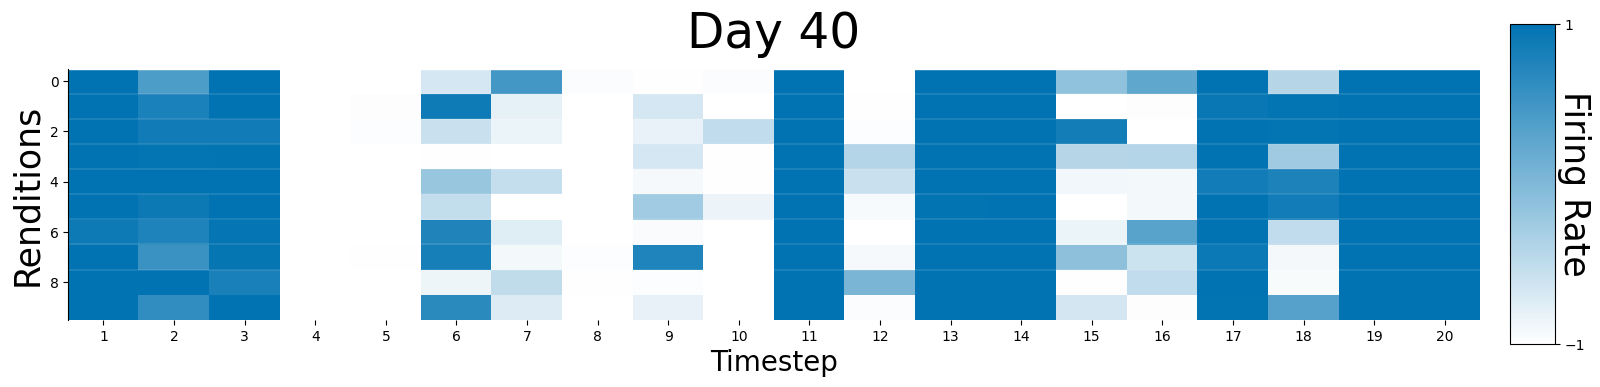

/tmp/ipykernel_3479060/3553538319.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Variability of a single neuron 4.664685048796521e-06
Mean var of all neurons: 0.15347897256331774
Stdev of variability of all neurons: 0.27309350952968964


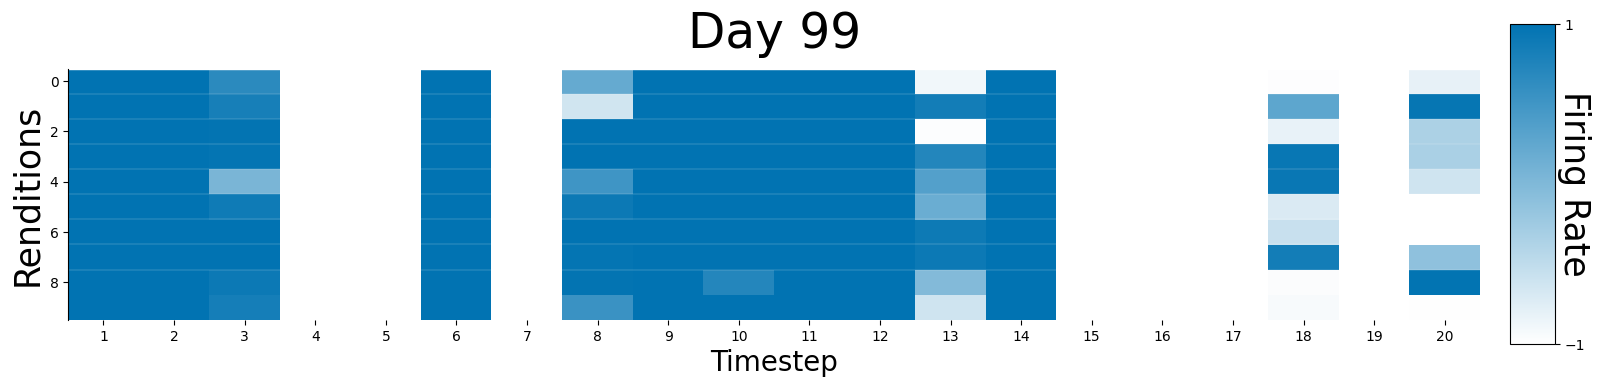

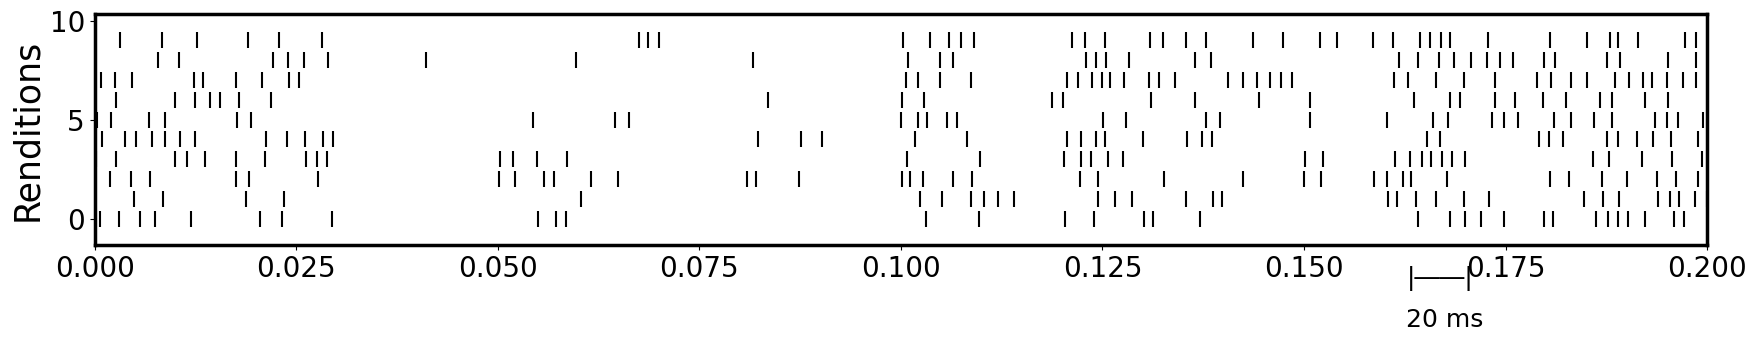

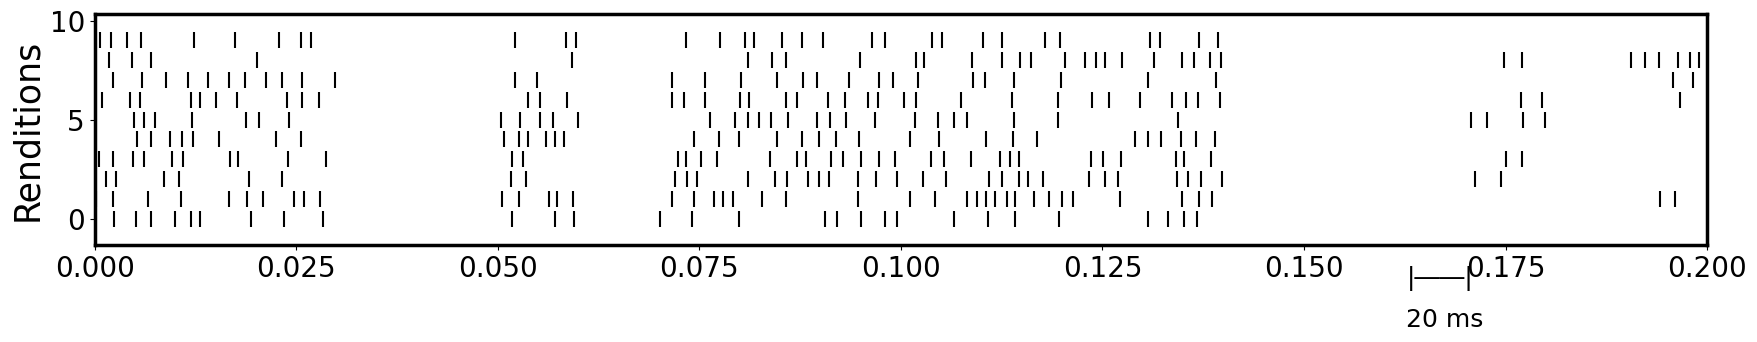

In [ ]:


def plot_HL_motifs_days_rate(obj, day):
    """ Plots the model output over time. """
    alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']  
    figure, (ax1) = plt.subplots(1, figsize=(15,4))
    # ra_all shape: (DAYS, TRIALS, N_SYLL, nos_neurons)
    cm = LinearSegmentedColormap.from_list('white_to_black', ['white', color_cortical])
    nos_trials_per_day = 10
    neuron_numbers = [1]
    nos_neurons = len(neuron_numbers)
    plot_array = obj.ra_all[day, :nos_trials_per_day, :, neuron_numbers].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T
    print("Variability of a single neuron", np.std(plot_array[5,:]))
    print("Mean var of all neurons:", np.mean(np.std(plot_array, axis = 1)))
    print("Stdev of variability of all neurons:", np.std(np.std(plot_array, axis = 1)))
    # plt.hist(plot_array.flatten(), bins=100, color='black', alpha=0.5)
    # plt.show()
    # plot_array = sigmoid(plot_array, m=1, a=0)
    # spike_raster = bin_and_plot_spikes(sigmoid(plot_array, m=1, a=0), factor=1, bin_size= 6)
    # spike_raster = plot_array
    im1 = ax1.imshow(plot_array.T, aspect='auto', cmap=cm, interpolation='nearest', vmin = -1, vmax = 1)   
    figure.subplots_adjust(right=1.2)
    cbar_ax = figure.add_axes([1.01, 0.12, 0.03, 0.8])
    cbar = figure.colorbar(im1, cax=cbar_ax)
    cbar.set_label('Firing Rate', fontsize=25, rotation = 270)
    cbar.set_ticks([-1, 1])
    # ax1.vlines(x=-0.5+np.arange(0, nos_trials_per_day*N_SYLL, N_SYLL), ymin =-0.5 , ymax = 7.5,  color='yellow', lw=1, label='Trials') 
    # ax1.set_xlim(0, 10*N_SYLL)
    # ax1.set_xticks(np.arange(0, N_SYLL*nos_trials_per_day*5, N_SYLL*nos_trials_per_day), day + np.arange(0, 5,1), fontsize=15)
    # ax1.set_xlim(0, 10*N_SYLL)
    # ax1.set_xticks()
    # ax1.set_xticks(np.arange(0, N_SYLL*10, N_SYLL), np.arange(0, 10), fontsize=15)
    ax1.hlines(y = np.arange(nos_neurons*8+1)-0.5, xmin = -0.5, xmax = N_SYLL*1-0.5, color='white', alpha = 0.1)
    ax1.hlines(y = np.arange(0,nos_neurons*8,8)-0.5, xmin = -0.5, xmax = N_SYLL*1-0.5, color='white', lw=1)      
    # ax1.set_yticks([])  
    # ax1.set_ylim(0, 7)
    # ax1.set_yticks(np.arange(8*nos_neurons), np.tile(np.arange(1, 9), nos_neurons), fontsize=15)
    ax1.set_xticks(np.arange(20), np.arange(1,21)) #, N_SYLL*nos_trials_per_day*spike_bins), day +40 + np.arange(0, 5,1), fontsize=15)
    ax1.tick_params(labelsize=10)
    ax1.set_title(f'Day {day+40}', fontsize=35, y = 1.05)
    ax1.set_ylabel('Renditions', fontsize=25)    
    ax1.set_xlabel('Timestep', fontsize=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)  
    ax1.spines['bottom'].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_HL_motifs_on_day_spike(obj, day, rate_max=400, rate_min=0.6, seed=None):
    """ Plots the model output over time. """
    alphabets = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']  
    figure, (ax1) = plt.subplots(1, figsize=(15,3))
    spike_bins = 1000
    nos_trials_per_day = 10
    neuron_numbers = [1]
    nos_neurons = len(neuron_numbers)
    plot_array = obj.ra_all[day, :nos_trials_per_day, :, neuron_numbers].reshape(nos_trials_per_day*nos_neurons, N_SYLL, order = 'F').T

    plot_array += 1
    plot_array /= 2
    # spike_raster = spike_plotter(plot_array, time_points_per_rate=20)
    # spike_raster = spike_plotter_poisson(plot_array, size_of_time_bin=20, scaling_factor=1)
    # im1 = ax1.imshow(spike_raster.T, aspect='auto', cmap='Greys', interpolation='nearest', vmin=0, vmax=1)
    spikes, time = poisson_eventplot_from_rates(plot_array, bin_size_ms=10, rate_max=rate_max, rate_min=rate_min, seed=seed)
    ax1.eventplot(
        spikes,
        orientation="horizontal",
        lineoffsets=np.arange(len(spikes)),
        linelengths=0.8,
        colors='black',)
    ax1.set_xlim(0, 0.01*N_SYLL)
    # ax1.vlines(x=-0.5+np.arange(0, nos_trials_per_day*N_SYLL*20, N_SYLL*20), ymin =-0.5 , ymax = 7.5,  color='red', lw=1)  
    # ax1.set_xlim(0, nos_trials_per_day*N_SYLL*20)
    figure.subplots_adjust(right=1.2)
    # cbar_ax = figure.add_axes([1.00, 0.2, 0.03, 0.53])
    # cbar = figure.colorbar(im1, cax=cbar_ax)
    # cbar.set_label('Rate', fontsize=15)
    # cbar.set_ticks([0, 1])
    # ax1.hlines(y = np.arange(nos_neurons*8+1)-0.5, xmin = 0, xmax = N_SYLL*20, color='black', alpha = 0.1)
    # ax1.hlines(y = np.arange(0,nos_neurons*8,8)-0.5, xmin = 0, xmax = N_SYLL*20, color='black', lw=1)
    # ax1.set_yticks([])
    # ax1.set_xticks([])
    # ax1.set_ylim(0, 7)
    # ax1.set_yticks(np.arange(8*nos_neurons), np.tile(np.arange(1, 9), nos_neurons), fontsize=15)
    # ax1.set_xticks(np.arange(50, N_SYLL*nos_trials_per_day*5*spike_bins, N_SYLL*nos_trials_per_day*spike_bins), day +40 + np.arange(0, 5,1), fontsize=15)
    ax1.tick_params(labelsize=20)
    # ax1.set_title(f'Day {day+40}', fontsize=20)
    ax1.set_ylabel('Renditions', fontsize=25)    
    # ax1.set_xlabel('Time (ms)', fontsize=20)
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')

# === Add timescale bar below axis (xlabel region) ===
    scalebar_len = 20  # ms
    bar_x0 = 1       # left position in figure coords (0 = far left, 1 = far right)
    bar_width = 0.05    # width in figure coords
    bar_y = -0.0      # vertical position below the axis

    figure.text(bar_x0, bar_y, '|' + '―'*2 + '|', fontsize=18, ha='left', va='center')
    figure.text(bar_x0 + bar_width/2, bar_y - 0.1, f'{scalebar_len} ms',
                ha='center', va='top', fontsize=18)



plot_HL_motifs_days_rate(obj,0)
plot_HL_motifs_days_rate(obj, 59) 

plot_HL_motifs_on_day_spike(obj,0, rate_max=400, rate_min=0.6)
plot_HL_motifs_on_day_spike(obj,59, rate_max=400, rate_min=0.6)

### C: BG neurons

In [ ]:
def plot_RL_motifs_days_rate(obj, day):
    """ Plots the BG model output over time (rate heatmap). """
    figure, ax1 = plt.subplots(1, figsize=(15,4))

    cm = colors.LinearSegmentedColormap.from_list('my_cmap', ['white', color_bg], N=256)
    nos_trials_per_day = 10
    neuron_numbers = [1]
    nos_neurons = len(neuron_numbers)

    plot_array = obj.bg_all[day, :nos_trials_per_day, :, neuron_numbers] \
                    .reshape(nos_trials_per_day*nos_neurons, N_SYLL, order='F').T
    print("Variability of a single neuron", np.std(plot_array[5,:]))
    print("Mean var of all neurons:", np.mean(np.std(plot_array, axis = 1)))
    print("Stdev of variability of all neurons:", np.std(np.std(plot_array, axis = 1)))
    im1 = ax1.imshow(plot_array.T, aspect='auto', cmap=cm,
                     interpolation='nearest', vmin=-1, vmax=1)

    # external colorbar
    figure.subplots_adjust(right=1.2)
    cbar_ax = figure.add_axes([1.01, 0.12, 0.03, 0.8])
    cbar = figure.colorbar(im1, cax=cbar_ax)
    cbar.set_label('Firing Rate', fontsize=25, rotation=270)
    cbar.set_ticks([-1, 1])

    # horizontal separators
    ax1.hlines(y=np.arange(nos_neurons*8+1)-0.5, xmin=-0.5, xmax=N_SYLL*1-0.5,
               color='white', alpha=0.1)
    ax1.hlines(y=np.arange(0, nos_neurons*8, 8)-0.5, xmin=-0.5, xmax=N_SYLL*1-0.5,
               color='white', lw=1)

    # ax1.set_yticks([])
    # ax1.set_ylim(0, 7)

    # xticks
    ax1.set_xticks(np.arange(20), np.arange(1, 21))
    ax1.tick_params(labelsize=10)

    # labels & title
    ax1.set_title(f'Day {day+40}', fontsize=35, y=1.05)
    ax1.set_ylabel('Renditions', fontsize=25)
    ax1.set_xlabel('Timestep', fontsize=20)

    # spines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_RL_motifs_on_day_spike(obj, day, rate_max=400, rate_min=0.6, seed=None):
    """ Plots the BG model output over time (spike raster). """
    figure, ax1 = plt.subplots(1, figsize=(15,3))

    nos_trials_per_day = 10
    neuron_numbers = [1]
    nos_neurons = len(neuron_numbers)
    plot_array = obj.bg_all[day, :nos_trials_per_day, :, neuron_numbers] \
                    .reshape(nos_trials_per_day*nos_neurons, N_SYLL, order='F').T

    # spike_raster = spike_plotter_poisson(plot_array, size_of_time_bin=20, scaling_factor=1)

    # im1 = ax1.imshow(spike_raster.T, aspect='auto', cmap='Greys',
    #                  interpolation='nearest', vmin=0, vmax=1)
    plot_array += 1
    plot_array /= 2
    spikes, time = poisson_eventplot_from_rates(plot_array, bin_size_ms=10, rate_max=rate_max, rate_min=rate_min, seed=seed)
    ax1.eventplot(
        spikes,
        orientation="horizontal",
        lineoffsets=np.arange(len(spikes)),
        linelengths=0.8,
        colors='black',)
    # # horizontal separators
    # ax1.hlines(y=np.arange(nos_neurons*8+1)-0.5, xmin=0, xmax=N_SYLL*20,
    #            color='black', alpha=0.1)
    # ax1.hlines(y=np.arange(0, nos_neurons*8, 8)-0.5, xmin=0, xmax=N_SYLL*20,
    #            color='black', lw=1)

    # ax1.set_yticks([])
    # ax1.set_xticks([])
    # ax1.set_ylim(0, 7)
    ax1.set_xlim(0, 0.01*N_SYLL)

    ax1.tick_params(labelsize=20)

    # labels & title
    ax1.set_ylabel('Renditions', fontsize=25)

    # make spines bold
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('black')

    # # === Add timescale bar below axis (xlabel region) ===
    # scalebar_len = 10  # ms
    # bar_x0 = 0.9       # left position in figure coords (center-ish)
    # bar_width = 0.05    # width in figure coords
    # bar_y = -0.08       # vertical position below axis

    # figure.text(bar_x0, bar_y, '|' + '―'*2 + '|', fontsize=18,
    #             ha='left', va='center')
    # figure.text(bar_x0 + bar_width/2, bar_y - 0.05,
    #             f'{scalebar_len} ms', ha='center', va='top', fontsize=18)

    plt.tight_layout()
    plt.show()



plot_RL_motifs_days_rate(obj,0)
plot_RL_motifs_days_rate(obj, 58) 

plot_RL_motifs_on_day_spike(obj,0, rate_max=200, rate_min=0.8)
plot_RL_motifs_on_day_spike(obj,58, rate_max=200, rate_min=0.8)

NameError: name 'obj' is not defined

In [ ]:
obj.ra_all.shape

(61, 1000, 20, 100)

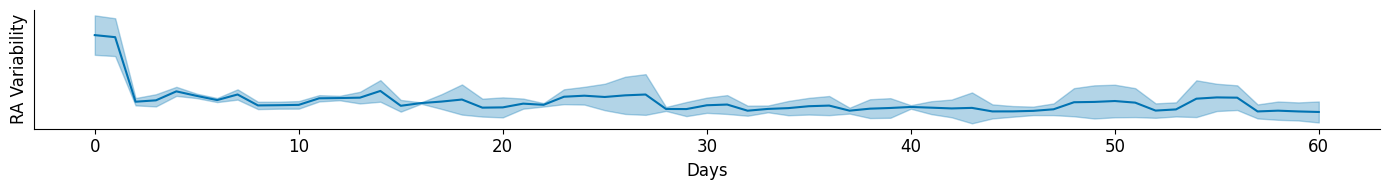

In [ ]:
def plot_ra_variability(obj):
    fig, ax = plt.subplots(1, 1, figsize=(14, 2))
    days = np.arange(DAYS)
    syll = 2  # choose syllable index

    # shape: (days, neurons)
    # for each day, for each neuron we compute std across time
    stds_per_neuron = []
    for day in days:
        bg_overtime = obj.ra_all[day, :, syll, :]  # shape: (1000 timepoints, 50 neurons)
        # std over time per neuron (axis=0: time dimension)
        stds = np.std(bg_overtime, axis=0)  # shape (50,)
        stds_per_neuron.append(stds)

    stds_per_neuron = np.array(stds_per_neuron)  # shape (days, neurons)

    # mean and SEM across neurons for each day
    mean_stds = np.mean(stds_per_neuron, axis=1)
    sem_stds = np.std(stds_per_neuron, axis=1) #/ np.sqrt(stds_per_neuron.shape[1])

    # optional running average
    mean_stds_running = running_std(mean_stds, window=2)
    sem_stds_running = running_std(sem_stds, window=2)

    # Plot thick line
    ax.plot(days, mean_stds_running, label=f"Syllable {syll}", color=color_cortical)

    # Plot shaded confidence interval (mean ± SEM)
    ax.fill_between(
        days,
        mean_stds_running - sem_stds_running,
        mean_stds_running + sem_stds_running,
        color=color_cortical,
        alpha=0.3,
        label="± SEM"
    )

    # Plot settings
    ax.set_ylabel("RA Variability", fontsize=12)
    ax.set_xlabel("Days", fontsize=12)
    ax.tick_params(labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()
plot_ra_variability(obj)